In [2]:
import os
import torch
import torch.nn as nn
import cv2
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
from PIL import Image
import math

device = torch.device("mps")


class InpaintGenerator(nn.Module):
    def __init__(self, in_channels=4, out_channels=3): # 4 ערוצים בכניסה!
        super(InpaintGenerator, self).__init__()

        def down_block(in_feat, out_feat, normalize=True):
            layers = [nn.Conv2d(in_feat, out_feat, 4, 2, 1, bias=False)]
            if normalize:
                layers.append(nn.InstanceNorm2d(out_feat))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers

        def up_block(in_feat, out_feat, dropout=0.0):
            layers = [
                nn.ConvTranspose2d(in_feat, out_feat, 4, 2, 1, bias=False),
                nn.InstanceNorm2d(out_feat),
                nn.ReLU(inplace=True)
            ]
            if dropout:
                layers.append(nn.Dropout(dropout))
            return layers

        # Encoder
        self.down1 = nn.Sequential(*down_block(in_channels, 64, normalize=False))
        self.down2 = nn.Sequential(*down_block(64, 128))
        self.down3 = nn.Sequential(*down_block(128, 256))
        self.down4 = nn.Sequential(*down_block(256, 512, normalize=False)) # Bottleneck
        
        # Decoder
        self.up1 = nn.Sequential(*up_block(512, 256))
        self.up2 = nn.Sequential(*up_block(512, 128)) # Skip connection doubles input
        self.up3 = nn.Sequential(*up_block(256, 64))
        
        self.final = nn.Sequential(
            nn.Upsample(scale_factor=2),
            nn.ZeroPad2d((1, 0, 1, 0)),
            nn.Conv2d(128, out_channels, 4, padding=1),
            nn.Tanh()
        )

    def forward(self, x):
        d1 = self.down1(x)
        d2 = self.down2(d1)
        d3 = self.down3(d2)
        d4 = self.down4(d3)
        
        u1 = self.up1(d4)
        u2 = self.up2(torch.cat([u1, d3], 1)) 
        u3 = self.up3(torch.cat([u2, d2], 1)) 
        
        return self.final(torch.cat([u3, d1], 1))


In [3]:

# ==========================================
# 2. פונקציות לוגיקה וגיאומטריה (שעון)
# ==========================================

def find_dynamic_clock_center(mask_hours, mask_minutes, image_shape):
    """
    מוצא את מרכז השעון על בסיס המחוגים.
    הלוגיקה: נקודת המרכז היא הפיקסל שנמצא בתוך המסכה (של אחד המחוגים)
    והוא הקרוב ביותר למרכז הגיאומטרי של התמונה.
    """
    h, w = image_shape[:2]
    geo_center = np.array([w // 2, h // 2])
    
    # איחוד המסכות כדי למצוא את "שורש" המחוגים
    combined_mask = np.maximum(mask_hours, mask_minutes)
    
    # מציאת כל הקואורדינטות שבהן יש מחוג
    # y_idxs, x_idxs הם מערכים של כל הנקודות הלבנות
    y_idxs, x_idxs = np.where(combined_mask > 0)
    
    if len(x_idxs) == 0:
        return (w // 2, h // 2) # Fallback if no hands detected

    # יצירת מערך של נקודות (N, 2)
    points = np.stack((x_idxs, y_idxs), axis=1)
    
    # חישוב מרחק אוקלידי בריבוע מכל נקודה במסכה למרכז התמונה הגיאומטרי
    # (x - cx)^2 + (y - cy)^2
    dists = np.sum((points - geo_center)**2, axis=1)
    
    # מציאת האינדקס של המרחק המינימלי
    min_idx = np.argmin(dists)
    
    # זהו מרכז השעון החדש!
    new_center = (int(points[min_idx][0]), int(points[min_idx][1]))
    return new_center

def get_hand_angle_dynamic(mask, center):
    """
    מחשב זווית ביחס למרכז הדינמי שקיבלנו.
    """
    y_idxs, x_idxs = np.where(mask > 0)
    if len(x_idxs) == 0:
        return 0

    # חישוב מרכז המסה של המחוג (Centroid) כדי לדעת לאן הוא מצביע
    centroid_x = np.mean(x_idxs)
    centroid_y = np.mean(y_idxs)

    # וקטור ממרכז השעון (הדינמי) למרכז המסה של המחוג
    vec_x = centroid_x - center[0]
    vec_y = centroid_y - center[1]

    angle_rad = math.atan2(-vec_y, vec_x)
    angle_deg = math.degrees(angle_rad)
    clock_angle = (90 - angle_deg) % 360
    return clock_angle

def get_hand_angle_from_mask(mask, center):
    """
    מחשב את זווית המחוג מתוך המסכה.
    0 מעלות = שעה 12:00.
    """
    y_idxs, x_idxs = np.where(mask > 0)
    if len(x_idxs) == 0:
        return 0

    centroid_x = np.mean(x_idxs)
    centroid_y = np.mean(y_idxs)

    # וקטור מהמרכז
    vec_x = centroid_x - center[0]
    vec_y = centroid_y - center[1] 

    # atan2 מחזיר זווית ברדיאנים ביחס לציר X חיובי (ימין)
    # y בתמונות גדל למטה, אז נהפוך סימן ל-y כדי לדמות צירים קרטזיים רגילים
    angle_rad = math.atan2(-vec_y, vec_x)
    angle_deg = math.degrees(angle_rad)

    # המרה לפורמט שעון (0 למעלה, עם כיוון השעון)
    # מתמטיקה: 0 זה ימין, 90 זה למעלה.
    # שעון: 0 זה למעלה, 90 זה ימין.
    clock_angle = (90 - angle_deg) % 360
    return clock_angle

def time_to_angle(hh, mm, hand_type='hour'):
    if hand_type == 'minute':
        return (mm / 60) * 360
    elif hand_type == 'hour':
        return ((hh % 12) / 12) * 360 + (mm / 60) * 30
    return 0

def rotate_hand_rgba(hand_rgba, current_angle, target_angle, center):
    """
    מסובב את שכבת המחוג (כולל ערוץ האלפא).
    """
    h, w = hand_rgba.shape[:2]
    angle_diff = target_angle - current_angle # זווית לסיבוב (עם כיוון השעון)
    
    # ב-OpenCV, זווית חיובית היא נגד כיוון השעון, לכן -angle_diff
    M = cv2.getRotationMatrix2D(center, -angle_diff, 1.0)
    
    # שימוש ב-BORDER_CONSTANT כדי שהשוליים החדשים יהיו שקופים
    rotated = cv2.warpAffine(
        hand_rgba, M, (w, h), 
        flags=cv2.INTER_LINEAR, 
        borderMode=cv2.BORDER_CONSTANT, 
        borderValue=(0,0,0,0) # RGBA שקוף לחלוטין
    )
    return rotated

def blend_images(background_rgb, foreground_rgba):
    """
    מבצע Alpha Blending בין רקע RGB לפורגראונד RGBA
    """
    # חילוץ ערוץ האלפא ונרמול ל-0-1
    alpha = foreground_rgba[:, :, 3] / 255.0
    alpha_3 = np.dstack((alpha, alpha, alpha))
    
    foreground_rgb = foreground_rgba[:, :, :3]
    
    # נוסחת הבלנדינג
    out = (foreground_rgb * alpha_3 + background_rgb * (1.0 - alpha_3))
    return out.astype(np.uint8)


In [4]:
# ==========================================
# 3. Pipeline ראשי
# ==========================================

def run_clock_pipeline(image_path, target_hh, target_mm, cgan_model, yolo_model):
    # --- א. טעינה ---
    img_pil = Image.open(image_path).convert('RGB')
    transform_resize = transforms.Resize((256, 256))
    img_resized = transform_resize(img_pil)
    img_cv = np.array(img_resized) 
    h, w, _ = img_cv.shape
    
    # --- ב. זיהוי מסכות ---
    mask_hours = np.zeros((h, w), dtype=np.uint8)
    mask_minutes = np.zeros((h, w), dtype=np.uint8)
    
    results = yolo_model(img_cv, verbose=False) 
    if results[0].masks is not None:
         masks_data = results[0].masks.data.cpu().numpy()
         classes = results[0].boxes.cls.cpu().numpy()
         for i, cls in enumerate(classes):
             m = cv2.resize(masks_data[i], (w, h), interpolation=cv2.INTER_NEAREST)
             if cls == 0: mask_hours = np.maximum(mask_hours, m) 
             elif cls == 1: mask_minutes = np.maximum(mask_minutes, m)

    # יצירת מסכה מלאה
    full_mask = np.maximum(mask_hours, mask_minutes)
    full_mask_bin = (full_mask > 0.5).astype(np.float32)
    mask_display = (full_mask_bin * 255).astype(np.uint8)

    # >>> חידוש: מציאת מרכז השעון הדינמי <<<
    dynamic_center = find_dynamic_clock_center(mask_hours, mask_minutes, img_cv.shape)
    # נצייר את המרכז על התמונה המקורית רק לצורך דיבאג (אופציונלי)
    # cv2.circle(img_cv, dynamic_center, 3, (255, 0, 0), -1) 

    # --- ג. ניקוי (CGAN) ---
    transform_norm = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
    
    img_tensor = transform_norm(img_resized).to(device)
    mask_tensor = torch.from_numpy(full_mask_bin).unsqueeze(0).to(device)
    mask_tensor = (mask_tensor - 0.5) / 0.5
    
    input_tensor = torch.cat([img_tensor, mask_tensor], dim=0).unsqueeze(0)
    
    with torch.no_grad():
        clean_generated = cgan_model(input_tensor)
    
    clean_generated = clean_generated.squeeze().permute(1, 2, 0).cpu().numpy()
    clean_generated = (clean_generated * 0.5 + 0.5) * 255
    clean_bg_rgb = np.clip(clean_generated, 0, 255).astype(np.uint8)

    # --- ד. מניפולציה וסיבוב ---
    final_output = clean_bg_rgb.copy()
    
    def process_hand_dynamic(mask, target_angle, img_src, current_bg, center_point):
        if np.sum(mask) == 0: return current_bg
        
        # חילוץ RGBA
        alpha_channel = (mask * 255).astype(np.uint8)
        b, g, r = cv2.split(img_src)
        hand_rgba = cv2.merge([b, g, r, alpha_channel])
        
        # חישוב זווית נוכחית לפי המרכז הדינמי
        curr_angle = get_hand_angle_dynamic(mask, center_point)
        
        # סיבוב סביב המרכז הדינמי
        rotated_hand = rotate_hand_rgba(hand_rgba, curr_angle, target_angle, center_point)
        
        return blend_images(current_bg, rotated_hand)

    # הזזת שעות
    angle_h = time_to_angle(target_hh, target_mm, 'hour')
    final_output = process_hand_dynamic(mask_hours, angle_h, img_cv, final_output, dynamic_center)
    
    # הזזת דקות
    angle_m = time_to_angle(target_hh, target_mm, 'minute')
    final_output = process_hand_dynamic(mask_minutes, angle_m, img_cv, final_output, dynamic_center)

    return img_cv, mask_display, clean_bg_rgb, final_output

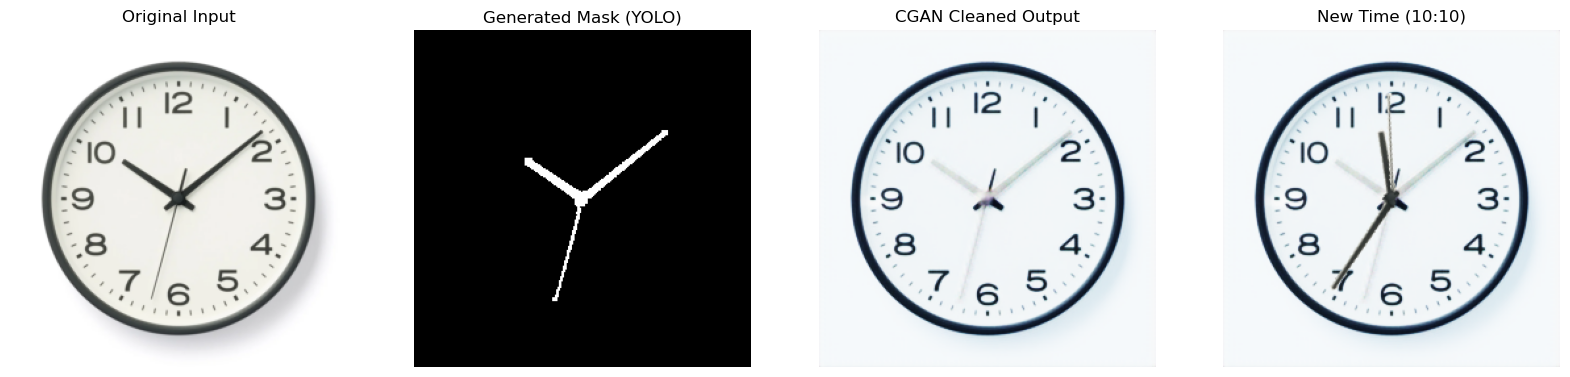

In [ ]:


# ==========================================
# 4. טעינה והרצה (Example)
# ==========================================

# 1. טעינת משקלים
cgan = InpaintGenerator().to(device)
weights_path = "analog-clock/cGAN/remove_hands/inpaint_gen_20.pth"
try:
    # מנסה לטעון ישירות ל-Device הנוכחי
    cgan.load_state_dict(torch.load(weights_path, map_location=device))
except RuntimeError:
    # אם זה נכשל (קורה לפעמים במעבר מ-CUDA ל-MPS), טוענים ל-CPU ואז מעבירים
    print("Direct load failed, loading to CPU first...")
    cgan.load_state_dict(torch.load(weights_path, map_location=torch.device('cpu')))
    cgan.to(device)
# 2. טעינת יולו (השלם את הטעינה שלך)
from ultralytics import YOLO
yolo = YOLO("analog-clock/yolo-detetct-hands/yolo_clock_hands_seg.pt") 

# 3. הרצה
# נתיב לתמונה
img_path = "analog-clock/test_images/test_image21.jpeg" 

if os.path.exists(img_path):
    # קריאה לפונקציה המעודכנת שמחזירה 4 ערכים
    original, mask, clean, result = run_clock_pipeline(img_path, 11, 30, cgan, yolo)

    # הגדרת פלוט רחב יותר ל-4 תמונות
    plt.figure(figsize=(20, 5))
    
    plt.subplot(1, 4, 1)
    plt.imshow(original)
    plt.title("Original Input")
    plt.axis('off')

    plt.subplot(1, 4, 2)
    plt.imshow(mask, cmap='gray') # הצגת המסכה בשחור לבן
    plt.title("Generated Mask (YOLO)")
    plt.axis('off')

    plt.subplot(1, 4, 3)
    plt.imshow(clean)
    plt.title("CGAN Cleaned Output")
    plt.axis('off')

    plt.subplot(1, 4, 4)
    plt.imshow(result)
    plt.title("New Time (10:10)")
    plt.axis('off')

    plt.show()
else:
    print(f"Image not found at: {img_path}")


# Fine-Tune the cGAN model on white background clocks and the yolo on thinner hands and also with secounds-hands